# Forecasting Item Sales

Using the forecasting module there are a few models we can use to predict a future demand distribution over a time period. We can use the data set () that has item sales for various items across various stores.

In [1]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pymc as pm

data_dir = Path('../data/demand-forecasting')
file_path = data_dir / 'train.csv'

df_train = pd.read_csv(file_path)

df_train.head()

,date,store,item,sales
0,2013-01-01,1,1,13
1,2013-01-02,1,1,11
2,2013-01-03,1,1,14
3,2013-01-04,1,1,13
4,2013-01-05,1,1,10


For now we are only concerned with the item sales across all stores to keep things simple. So we sum item sales across the stores and drop the store column.

In [2]:
df_items = df_train.groupby(["date", "item"]).sum().reset_index().drop(columns="store")
df_items

,date,item,sales
0,2013-01-01,1,133
1,2013-01-01,2,327
2,2013-01-01,3,172
3,2013-01-01,4,102
4,2013-01-01,5,83
...,...,...,...
91295,2017-12-31,46,605
91296,2017-12-31,47,211
91297,2017-12-31,48,494
91298,2017-12-31,49,285


## Parametric Model Creation

The first model is a parametric Bayesian time series model. First lets isolate the sales for one of the items

<Axes: xlabel='date', ylabel='sales'>

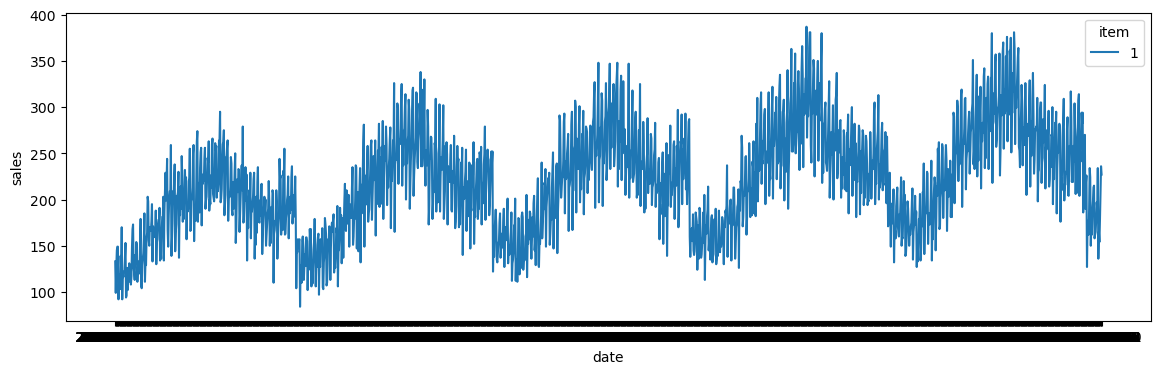

In [3]:
# select item
item = 1
df = df_items[df_items["item"] == item]

fig, ax = plt.subplots(1, 1, figsize=(14, 4))
sns.lineplot(data=df.reset_index(), x="date", y="sales", hue="item", ax=ax)

We can then construct the model using a seasonality config `dict`. We can specify periods for our fourier series, as well as number of harmonics for this period.

We can then also create events, peirods of time where we believe sales will differ from typical patterns, using the `create_events` method. We can create any number of events, each of which can run for any period of time and repeat any number of time. Below we create a black friday event as well as Saturday event as examples. **Note**: for these events we need to specify dates outside the training data range where we want to create forecasts of the sale numbers.

We withhold the last 90 days of the data to later validate the model, only train it on the rest of the data.

In [4]:
from optistock.forecasting import BayesTimeSeries

default_seasonal_config = {
    "weekly": (7, 3),
    "monthly": (30.5, 1),
    "yearly": (365.25, 4),
}

df["date"] = pd.to_datetime(df["date"])
df_train = df.iloc[:-90,:]
bayes_model = BayesTimeSeries(df_train, seasonal_config=default_seasonal_config)

black_friday_full = (
    df.set_index("date")
    .index.to_series()
    .apply(lambda x: True if (x.month == 11 and 1 <= x.day <= 29) else False)
)
true_dates_bf = black_friday_full[black_friday_full].index.tolist()

Saturday_full = (
    df.set_index("date")
    .index.dayofweek.to_series()
    .apply(lambda x: True if (x == 6) else False)
)
true_dates_saturday = black_friday_full[black_friday_full].index.tolist()

idata_model = bayes_model.create_events(
    {"black_friday": true_dates_bf, "saturdays": true_dates_saturday}
).fit()

C:\Users\bouwe\AppData\Local\Temp\ipykernel_35004\962182191.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["date"] = pd.to_datetime(df["date"])
Initializing NUTS using jitter+adapt_diag...
c:\Users\bouwe\anaconda3\envs\inventory_env\Lib\site-packages\pytensor\link\c\cmodule.py:2986: UserWarning: PyTensor could not link to a BLAS installation. Operations that might benefit from BLAS will be severely degraded.
This usually happens when PyTensor is installed via pip. We recommend it be installed via conda/mamba/pixi instead.
Alternatively, you can use an experimental backend such as Numba or JAX that perform their own BLAS optimizations, by setting `pytensor.config.mode == 'NUMBA'` or passing `mode='NUMBA'` when compiling a PyTensor function

Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 101 seconds.
Sampling: [y]


Output()

## View Model Fit Results

We can then view the perceived impact the various components of the model using the `plot_components()` method.

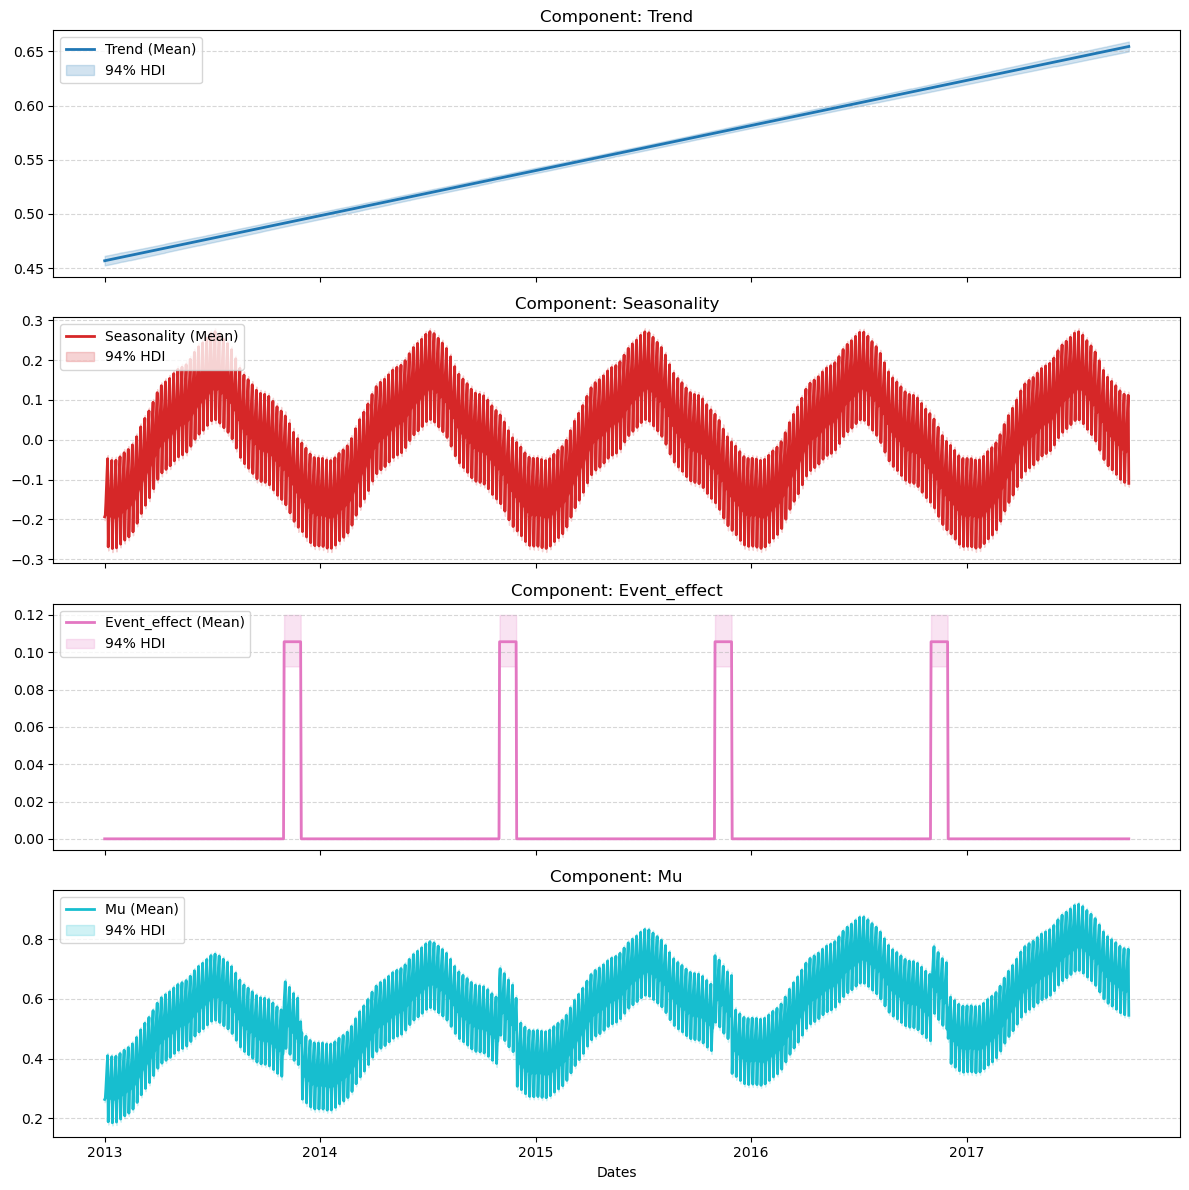

In [5]:
fig, ax = bayes_model.plot_components()

If we are happy with the model, we can then use it to generate predictions of future sale numbers. Here we ask it to predict the next 90 days of sales.

In [6]:
actual = df[["date", "sales"]].iloc[-90:]
df_future = pd.DataFrame({"date": pd.date_range(actual["date"].iloc[0], periods=90)})
forecast = bayes_model.predict(df_future)

Sampling: [y]


Output()

Using the `plot_forecast()` we can plot these predictions and verify them against the actual results. As we are using a Bayesian model we also plot the 95% HDI.

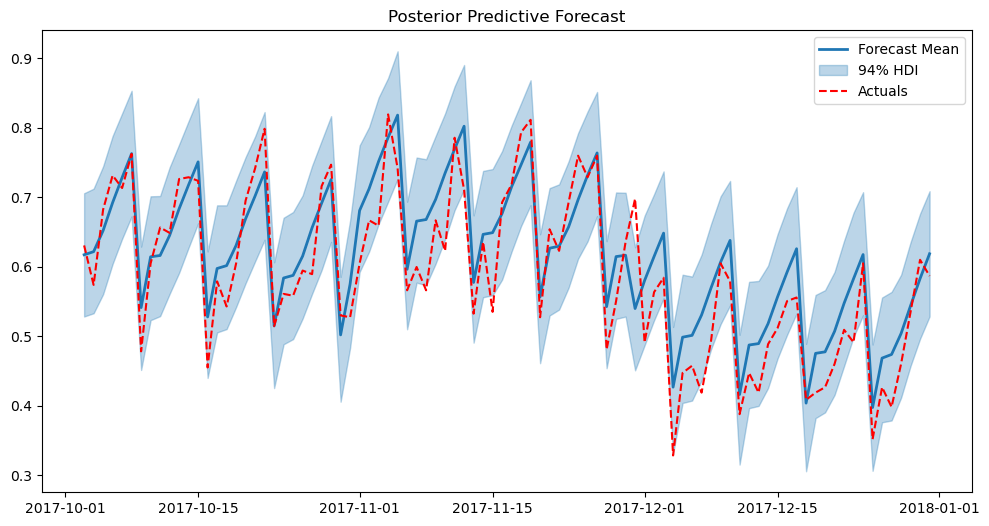

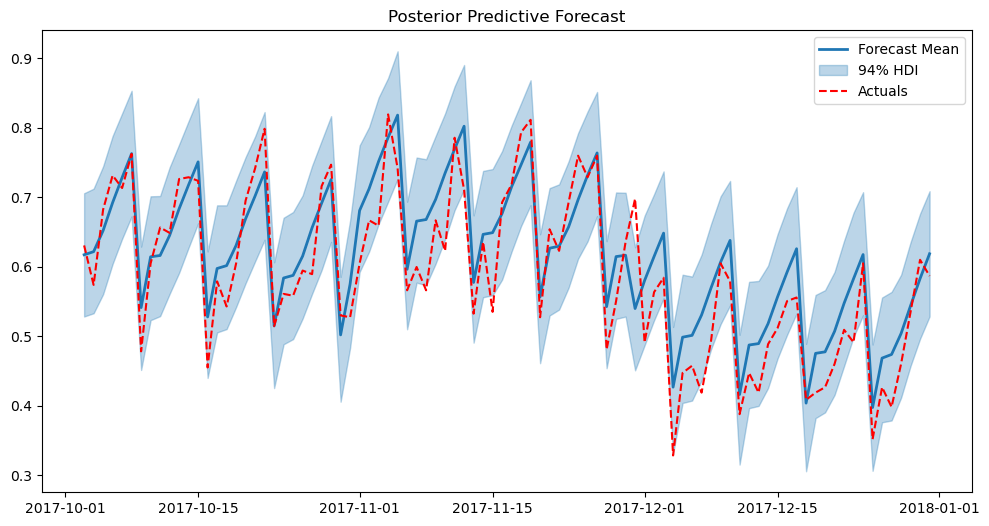

In [7]:
fig, ax = bayes_model.plot_forecast()
ax.plot(actual["date"], actual["sales"].div(bayes_model.max_scaler), "r--", label = "Actuals")
ax.legend()
fig

We can then calculate the error of the prediction and the actual sales numbers.

In [23]:
from optistock.forecasting import ErrorEstimations
smape = ErrorEstimations.calculate_smape 
smape(
    df["sales"].iloc[-90:].div(bayes_model.max_scaler),
    forecast.predictions["y"].mean(dim=("chain", "draw"))[-90:],
)

np.float64(7.782243515128119)

## Demand Estimation

We can then use the `get_demand_distribution` to get the demand distribution for any time period inside the forecast period

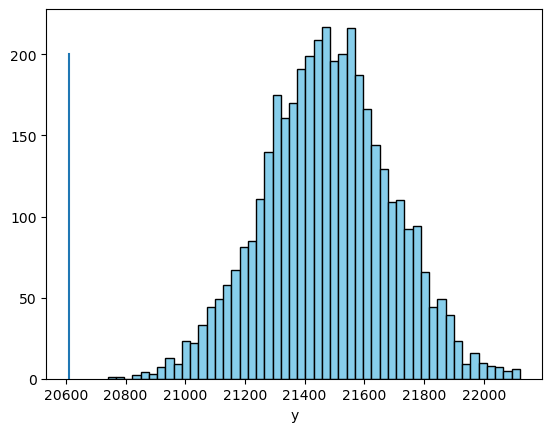

In [9]:
esti_demand = bayes_model.get_demand_distribution(start_date="2017-10-03", end_date="2017-12-31")

fig = esti_demand['y'].plot.hist(bins=50, color='skyblue', edgecolor='black')
plt.plot([actual["sales"].sum(), actual["sales"].sum()], [0, 200])

## Non-Parametric Model Creation

To create a non-parametric model, in this case a Bayesian Additive Regression Tree (BART) model, we follow exactly the same steps as before. **Note**, on average these models will take longer to train, and if issues in training happen they tend to be harder to diagnose due to the 'black-box' nature of the model.

In [15]:
from optistock.forecasting import BARTBayesTimeSeries

model = BARTBayesTimeSeries(df_train)
idata = model.fit(samples=2000, trees=100)

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>NUTS: [intercept, growth, sigma]
>PGBART: [bart]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 174 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


### View Model Fit Results

Although not quite the same, we can view the impact of each covariant *on average* on the model output.

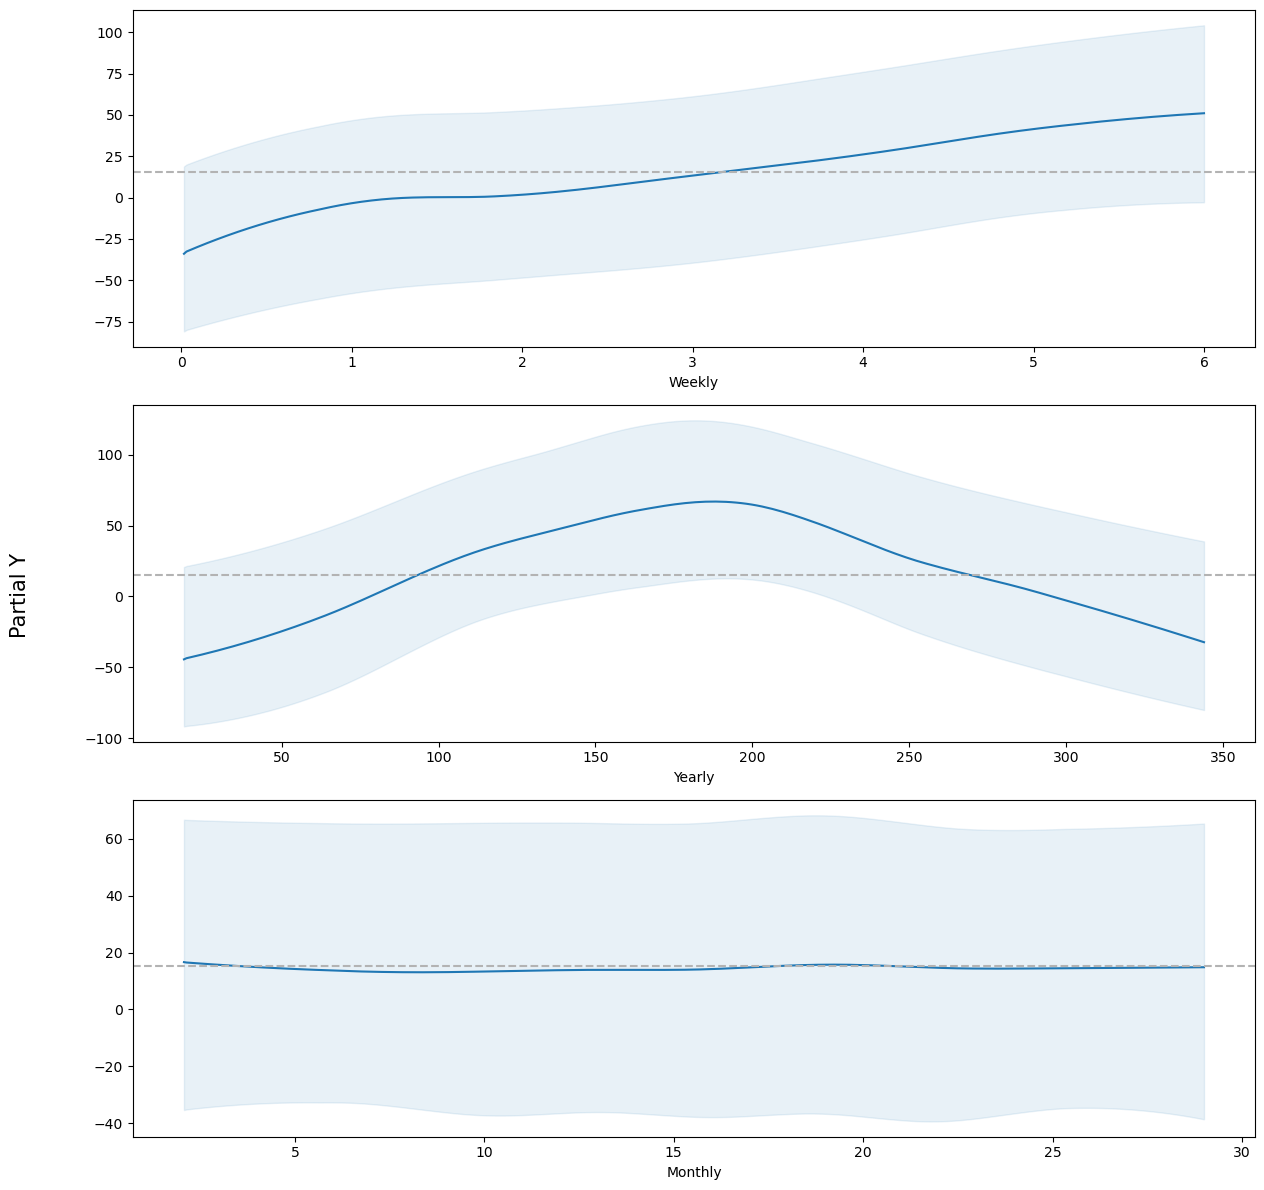

In [16]:
fig, ax = model.plot_components()

Again, lets as the model to predict the next 90 days of sales.

Sampling: [bart, y]


Output()

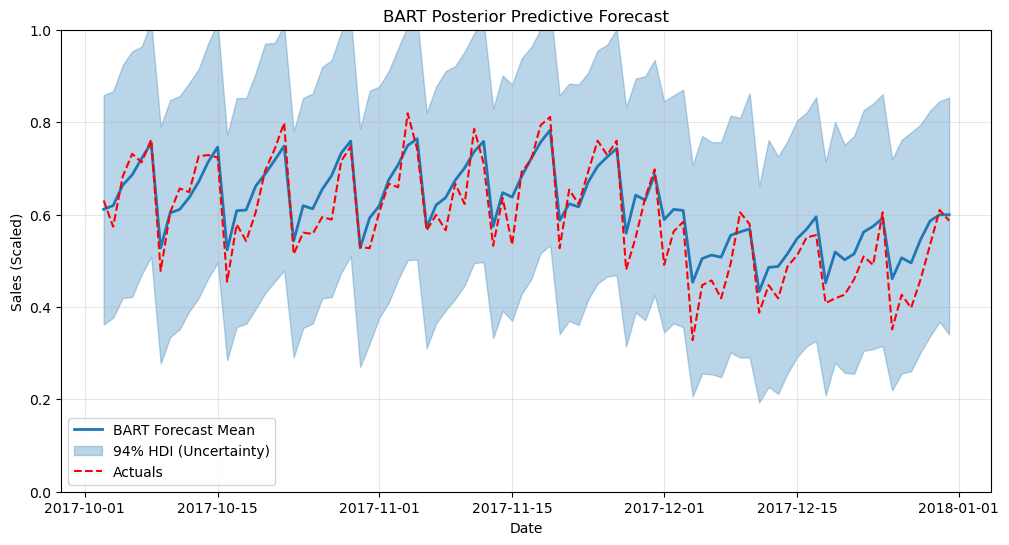

In [17]:
actual = df[["date", "sales"]].iloc[-90:]
df_future = pd.DataFrame({"date": pd.date_range(actual["date"].iloc[0], periods=90)})
forecast = model.predict(df_future)
fig, ax = model.plot_forecast()
ax.plot(actual["date"], actual["sales"].div(bayes_model.max_scaler), "r--", label = "Actuals")
ax.legend()

The error between the estimate and the actual sales is then

In [24]:
smape(actual["sales"].div(bayes_model.max_scaler), forecast.predictions["y"].mean(dim=("chain", "draw"))[-90:])

np.float64(7.782243515128119)

We then estimate the demand over a period the same as before

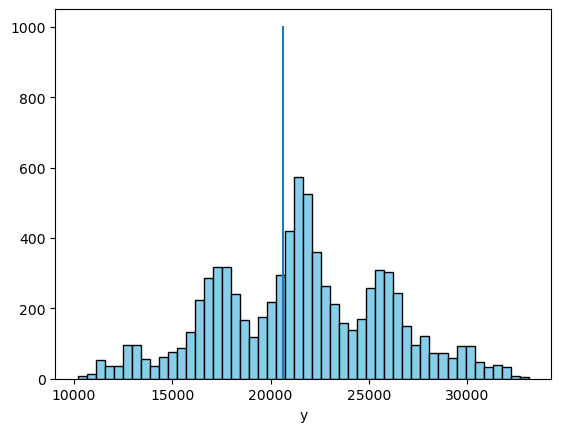

In [19]:
esti_demand = model.get_demand_distribution(start_date="2017-10-03", end_date="2017-12-31")
fig = esti_demand.plot.hist(bins=50, color='skyblue', edgecolor='black')
plt.plot([actual["sales"].sum(), actual["sales"].sum()], [0, 1000])
